In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, zscore


In [ ]:
df = pd.read_csv("INDUSTRY.csv")


In [ ]:
df.head()
df.info()
df.shape
df.describe()
df.isnull().sum()
df.nunique()


<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      15000 non-null  int64  
 1   company_name            15000 non-null  str    
 2   industry                15000 non-null  str    
 3   country                 15000 non-null  str    
 4   employee_count          15000 non-null  int64  
 5   annual_revenue_million  15000 non-null  float64
 6   profit_margin_percent   15000 non-null  float64
 7   founded_year            15000 non-null  int64  
 8   customer_count          15000 non-null  int64  
 9   market_rating           15000 non-null  float64
 10  created_date            15000 non-null  str    
 11  region                  15000 non-null  str    
dtypes: float64(3), int64(4), str(5)
memory usage: 1.4 MB


id                        15000
company_name              15000
industry                      5
country                       4
employee_count             4754
annual_revenue_million    13935
profit_margin_percent      3924
founded_year                 30
customer_count            13946
market_rating                51
created_date                790
region                        3
dtype: int64

## Univariate Analysis

In [ ]:
num_cols = ['employee_count',
            'annual_revenue_million',
            'profit_margin_percent',
            'founded_year',
            'customer_count',
            'market_rating']

for col in num_cols:
    print(f"\n{col}")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Std:", df[col].std())
    print("Skewness:", skew(df[col]))
    print("Kurtosis:", kurtosis(df[col]))
    


employee_count
Mean: 2606.8620666666666
Median: 2587.0
Std: 1430.5625126902273
Skewness: 0.0023532837281356905
Kurtosis: -1.1876991675841688

annual_revenue_million
Mean: 549.7327066666667
Median: 543.9200000000001
Std: 288.24412840517317
Skewness: 0.027338494990466998
Kurtosis: -1.1870634023152409

profit_margin_percent
Mean: 25.01201933333333
Median: 24.91
Std: 11.526186847110734
Skewness: 0.0025600913990232784
Kurtosis: -1.20256527476831

founded_year
Mean: 2004.374
Median: 2004.0
Std: 8.606687070963435
Skewness: 0.020602789755811004
Kurtosis: -1.1896124321980361

customer_count
Mean: 50449.251866666666
Median: 50726.5
Std: 28744.63883020963
Skewness: -0.004865441117368913
Kurtosis: -1.1947153719090147

market_rating
Mean: 2.5137799999999997
Median: 2.5
Std: 1.4479976604775011
Skewness: -0.020031465411877128
Kurtosis: -1.2057588701018218


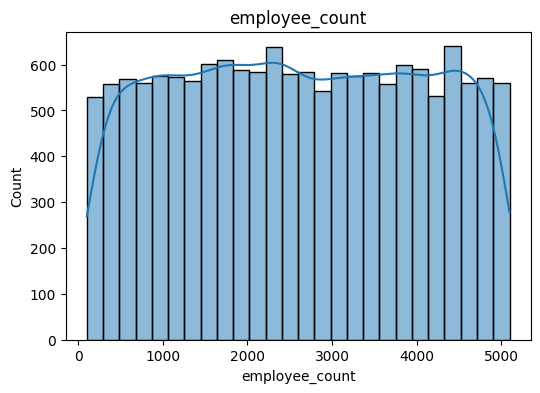

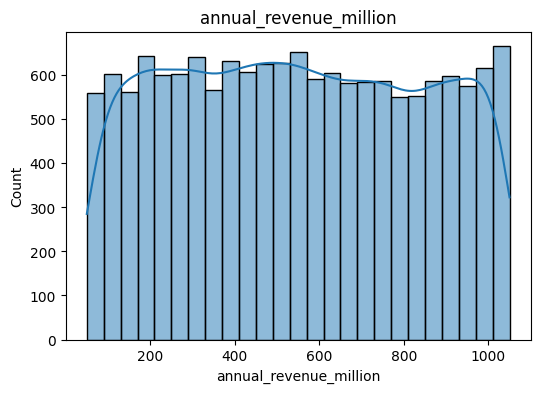

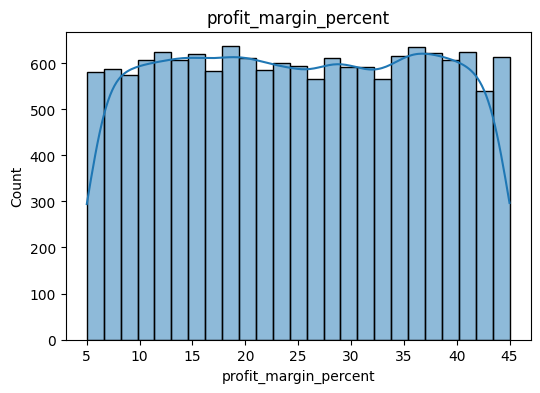

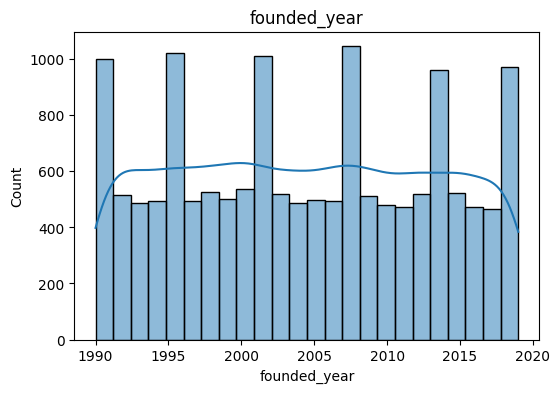

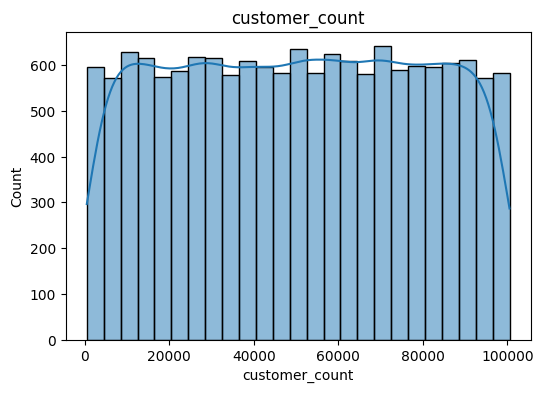

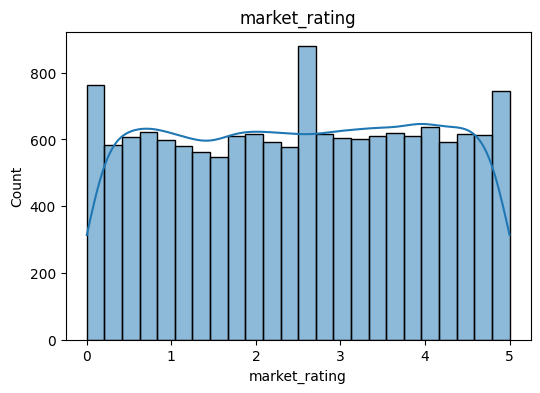

In [5]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()
    

In [6]:
cat_cols = ['industry','country','region']

for col in cat_cols:
    print(df[col].value_counts())
    

industry
Finance          3000
Technology       3000
Retail           3000
Manufacturing    3000
Healthcare       3000
Name: count, dtype: int64
country
India      3750
Germany    3750
Canada     3750
USA        3750
Name: count, dtype: int64
region
North America    7500
Asia             3750
Europe           3750
Name: count, dtype: int64


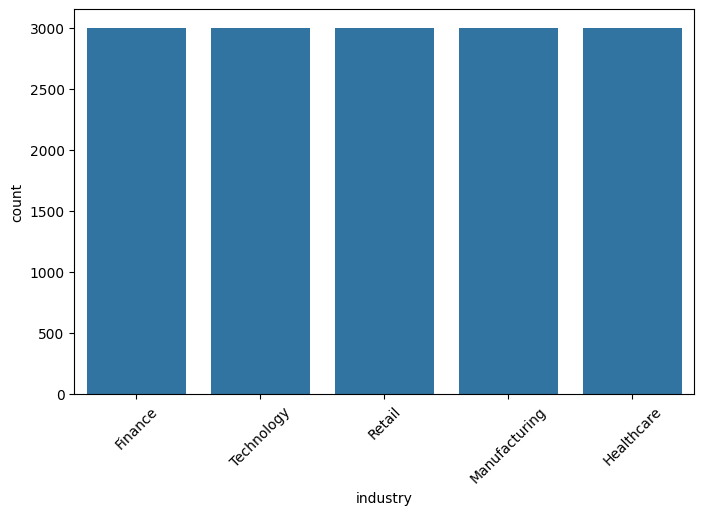

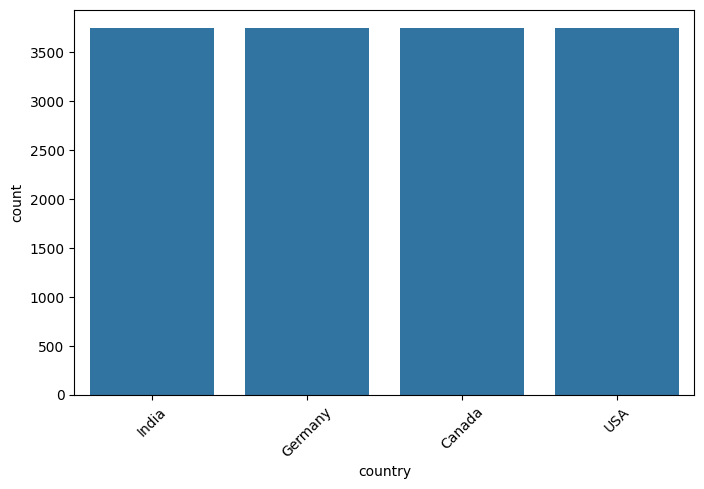

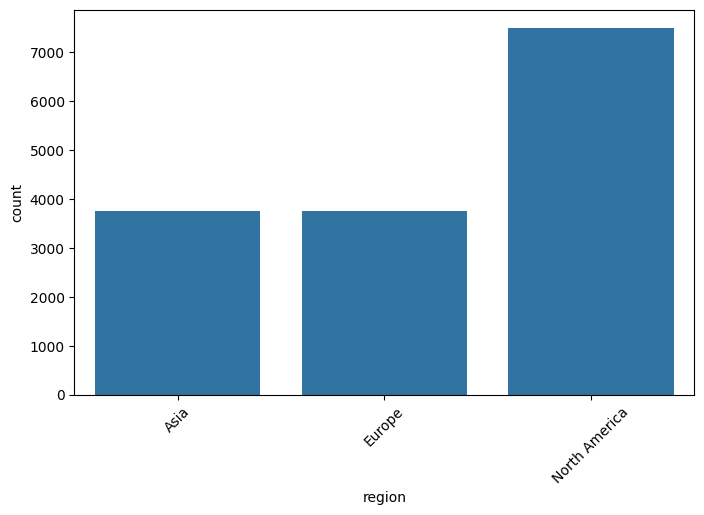

In [7]:
for col in cat_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df,x=col)
    plt.xticks(rotation=45)
    plt.show()
    

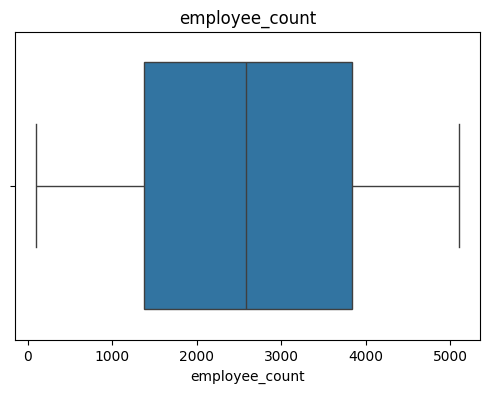

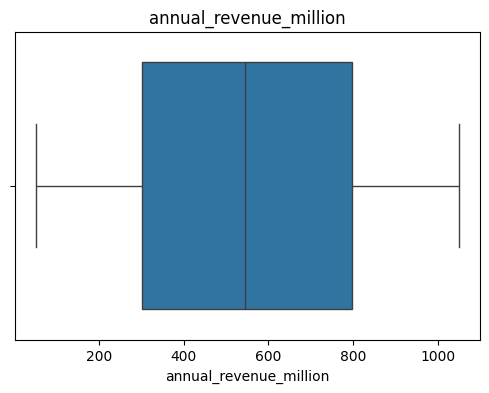

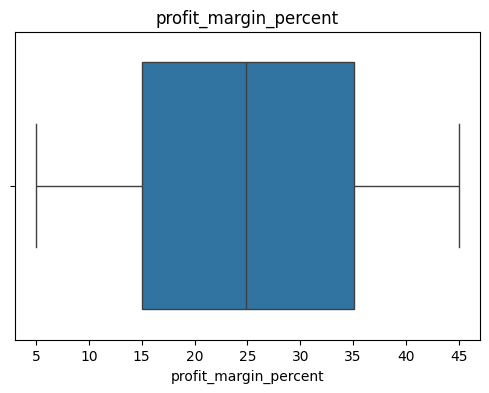

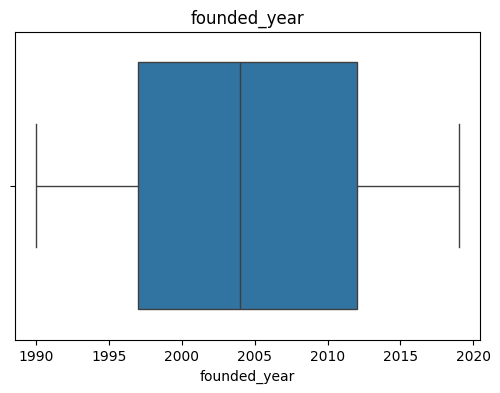

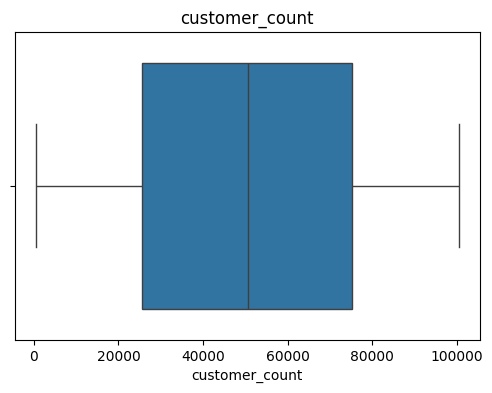

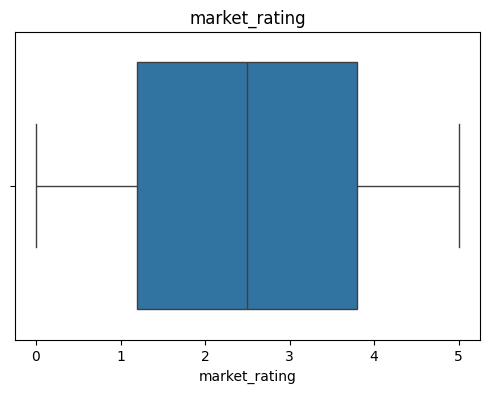

In [8]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()
    

In [9]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, len(outliers))
    

employee_count 0
annual_revenue_million 0
profit_margin_percent 0
founded_year 0
customer_count 0
market_rating 0


In [10]:
z_scores = np.abs(zscore(df[num_cols]))

outliers = (z_scores > 3).sum(axis=0)

for col, count in zip(num_cols,outliers):
    print(col,count)
    

employee_count 0
annual_revenue_million 0
profit_margin_percent 0
founded_year 0
customer_count 0
market_rating 0


## Bivariate Analysis

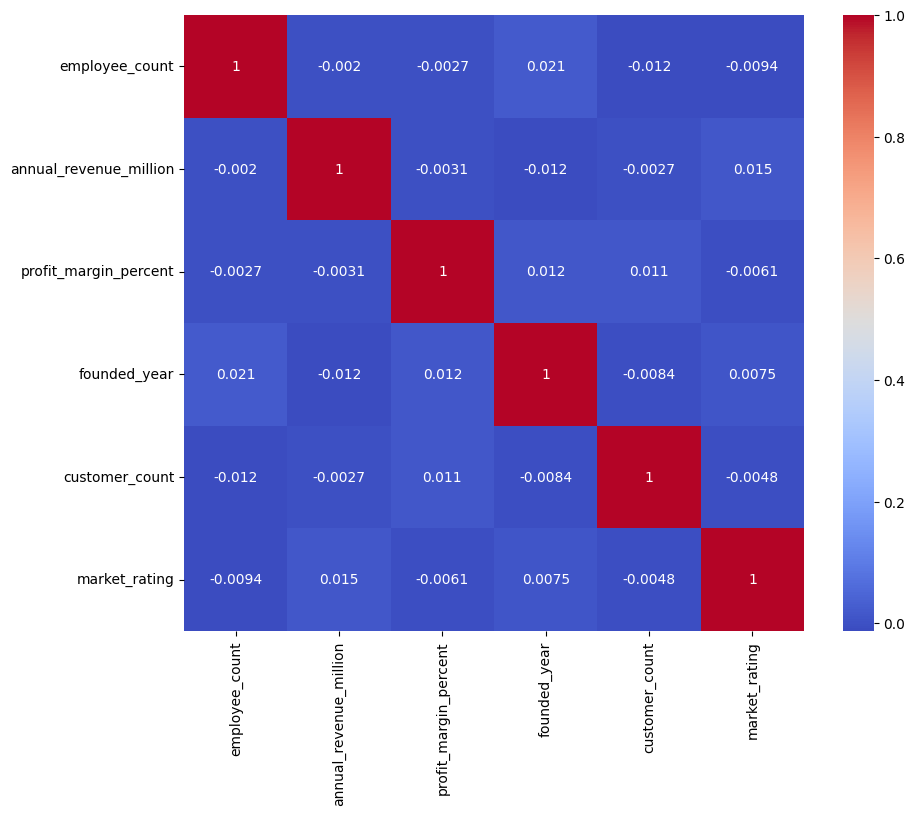

In [11]:
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')
plt.show()


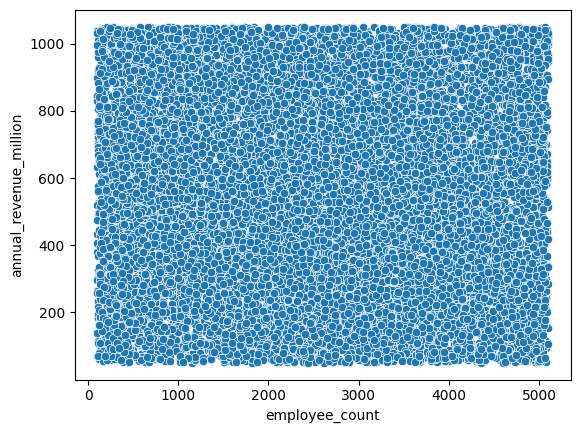

In [12]:
sns.scatterplot(
    data=df,
    x='employee_count',
    y='annual_revenue_million'
)

plt.show()


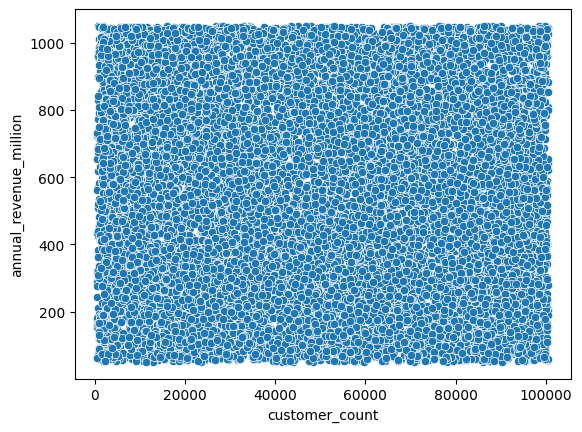

In [13]:
sns.scatterplot(
    data=df,
    x='customer_count',
    y='annual_revenue_million'
)

plt.show()


### Industry vs Revenue

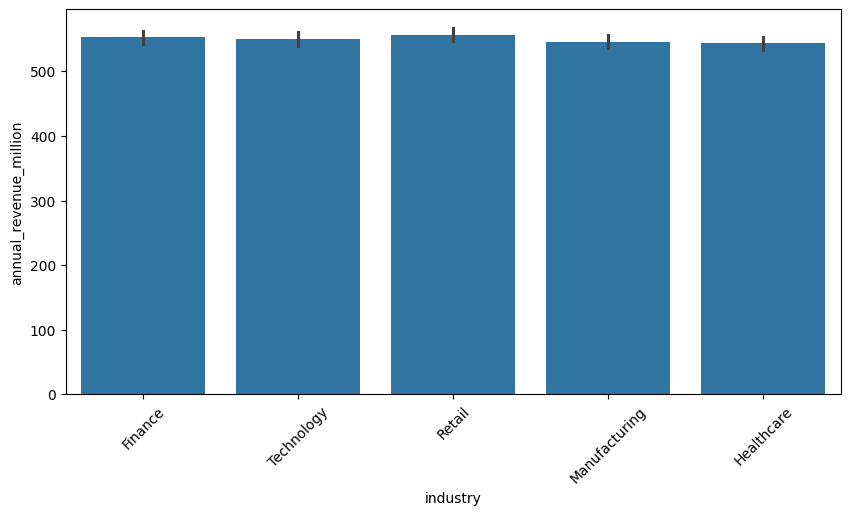

In [14]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df,
    x='industry',
    y='annual_revenue_million'
)
plt.xticks(rotation=45)
plt.show()


### Region vs Employee Count

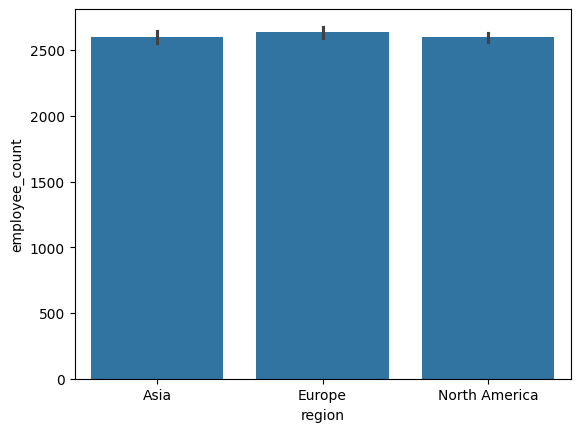

In [15]:
sns.barplot(
    data=df,
    x='region',
    y='employee_count'
)
plt.show()


### Country vs Market Rating

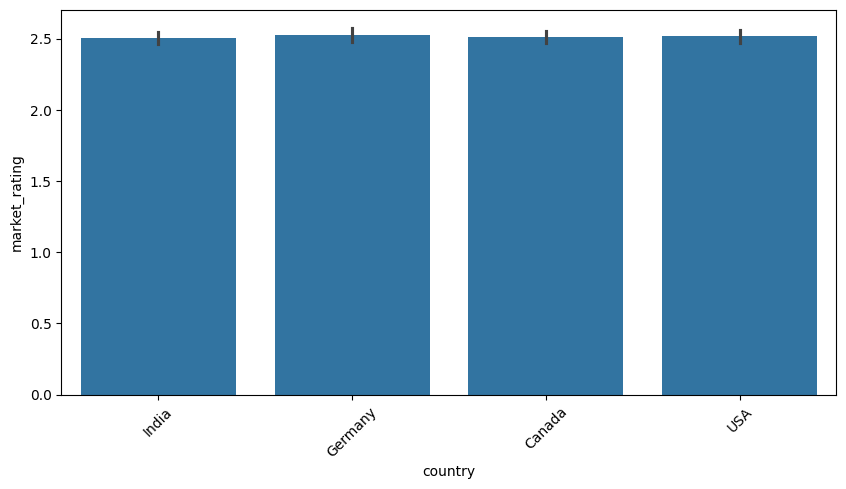

In [16]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df,
    x='country',
    y='market_rating'
)
plt.xticks(rotation=45)
plt.show()


## Multivariate Analysis

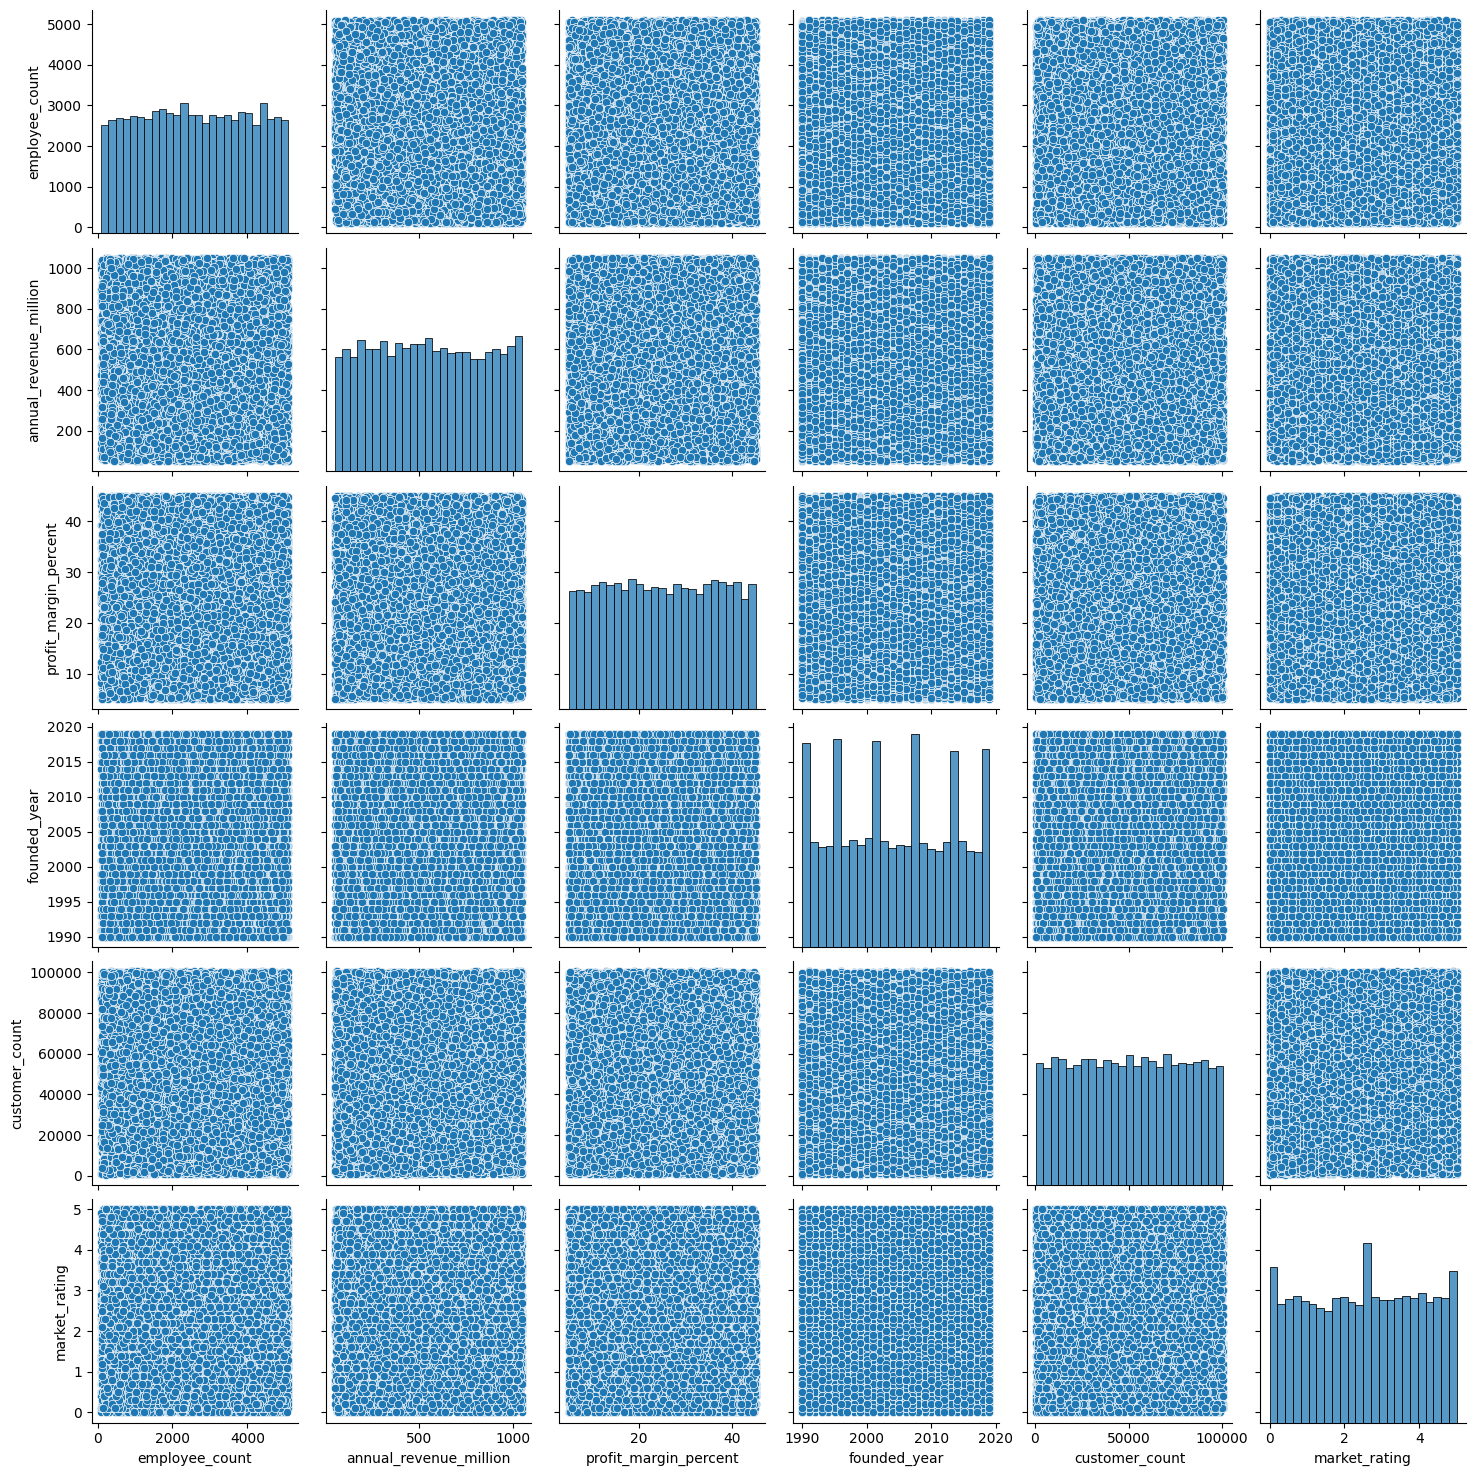

In [17]:
sns.pairplot(df[num_cols])
plt.show()


### Industry × Revenue × Employee Count

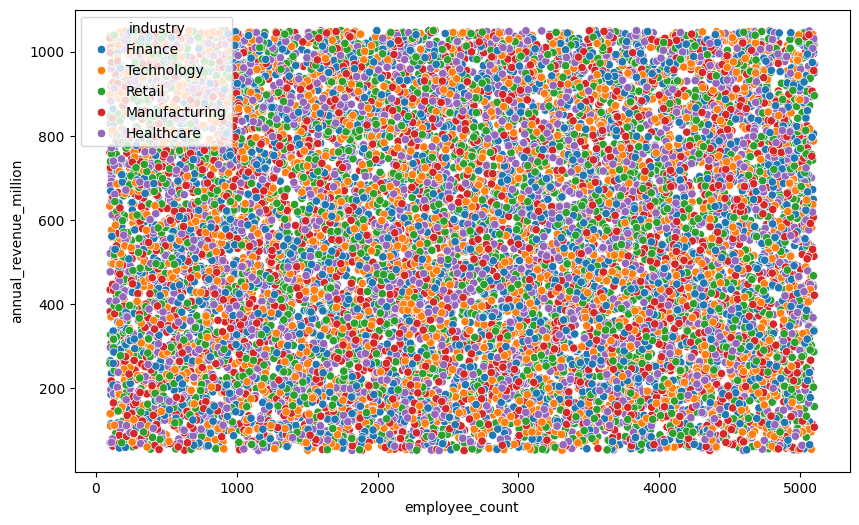

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='employee_count',
    y='annual_revenue_million',
    hue='industry'
)

plt.show()


## MACHINE LEARNING

In [19]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

le = LabelEncoder()

for col in ['industry','country','region']:
    df_ml[col] = le.fit_transform(df_ml[col])

df_ml.drop(['id',
            'company_name',
            'created_date'],
           axis=1,
           inplace=True)


In [20]:
X = df_ml.drop('annual_revenue_million',axis=1)

y = df_ml['annual_revenue_million']


In [21]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error

lr = LinearRegression()

lr.fit(X_train,y_train)

pred = lr.predict(X_test)

print("R2:",r2_score(y_test,pred))
print("MAE:",mean_absolute_error(y_test,pred))


R2: -0.0003537595781053504
MAE: 248.36231971494482


In [23]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print("R2:",r2_score(y_test,pred_rf))
print("MAE:",mean_absolute_error(y_test,pred_rf))


R2: -0.03475912830533279
MAE: 251.0855091833334


In [27]:
comparison = pd.DataFrame({
    'Model':['Linear Regression','Random Forest'],
    'R2 Score':[
        r2_score(y_test,pred),
        r2_score(y_test,pred_rf)
    ],
    'MAE':[
        mean_absolute_error(y_test,pred),
        mean_absolute_error(y_test,pred_rf)
    ]
})

comparison


,Model,R2 Score,MAE
0,Linear Regression,-0.000354,248.362320
1,Random Forest,-0.034759,251.085509


### Business Insights


Employee count and customer count show a positive relationship with annual revenue.

Revenue distribution is positively skewed.

Technology and Retail industries dominate revenue generation.

Large enterprises contribute significantly to overall market revenue.

Outliers represent genuine large-scale companies and should be retained.